# Assignment 1 
## Problem 1.1
This notebook is used to set up the 2D diffusion problem of the first CFD assignment.

We consider the concentration field $c(x,y,t)$ governed by

$$
\frac{\partial c}{\partial t} = \nabla \cdot (\alpha \nabla c),
$$

where the diffusion coefficient $\alpha$ is much larger in the liquid corridors than in the solid walls.

The goals of Problem 1.1:
1. define the diffusion coefficient field,
2. impose the inlet and outlet boundary conditions,
3. impose no-flux conditions on the remaining outer boundaries.

### Physical interpretation

The diffusive flux is given by

$$
\mathbf{J} = -\alpha \nabla c.
$$

Since the diffusion coefficient in the liquid is much larger than in the walls,

$$
\alpha_{\text{liquid}} \gg \alpha_{\text{wall}},
$$

transport through the liquid corridors is much stronger than transport through the walls.

Therefore, the walls act almost like impermeable barriers, and the dye mainly spreads through the connected corridor network from inlet to outlet.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

### Domain and geometry

The computational domain is the unit square:

$$
\Omega = [0,1] \times [0,1].
$$

The maze geometry is provided as a binary array:
- `0` = liquid
- `1` = wall

We use this geometry to define the spatially varying diffusion coefficient: 
The diffusion coefficient are thus defined as:

$$
\alpha(x,y)=
\begin{cases}
10^{-1}, & \text{in the liquid region}, \\
10^{-8}, & \text{in the wall region}.
\end{cases}
$$

This large contrast ensures that diffusion through the walls is negligible compared to diffusion through the corridors.

In [15]:
# Domain
Lx = Ly = 1.0
Nx = Ny = 50
dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(0.5 * dx, Lx - 0.5 * dx, Nx)
y = np.linspace(0.5 * dy, Ly - 0.5 * dy, Ny)
X, Y = np.meshgrid(x, y)

# Load maze geometry and create diffusion field
I = np.load("maze_geometry.npy")

alpha_wall = 1e-8
alpha_liquid = 1e-1

alpha = alpha_liquid * (1.0 - I) + alpha_wall * I

The following visualizes the spatial distribution of the diffusion coefficient.

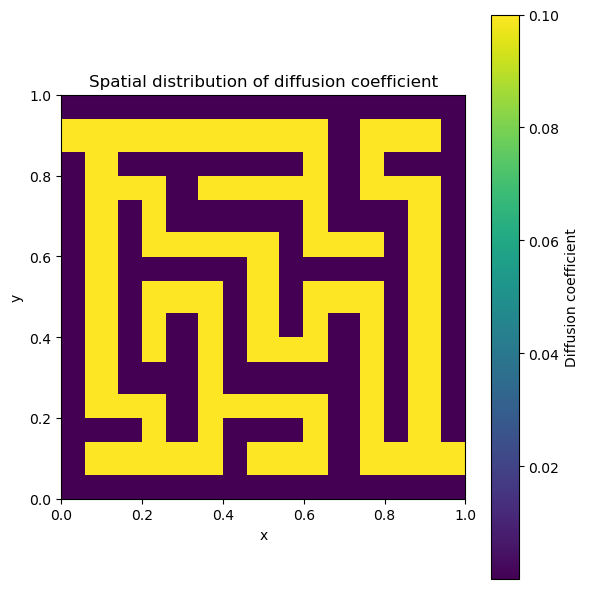

In [16]:
plt.figure(figsize=(6, 6))
plt.imshow(alpha, origin="lower", extent=[0, 1, 0, 1], aspect="equal")
plt.colorbar(label="Diffusion coefficient")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spatial distribution of diffusion coefficient")
plt.tight_layout()
plt.show()

## Problem 1.3 - 1.4 
### Initial concentration and boundary conditions

The initial concentration is

$$
c(x,y,0)=0.
$$

At the inlet on the left boundary, we impose

$$
c(0,y,t)=1, \qquad 0.86 < y < 0.94.
$$

At the outlet on the right boundary, we impose

$$
c(1,y,t)=0, \qquad 0.06 < y < 0.14.
$$

On all other outer boundaries, we impose a no-flux condition:

$$
-\alpha \frac{\partial c}{\partial n}=0,
$$

which is equivalent to

$$
\frac{\partial c}{\partial n}=0.
$$

### Implementation of the boundary conditions

Dirichlet conditions on a boundary face:

$$
c_{\text{ghost}} = 2c_B - c_{\text{inside}},
$$

For Neumann conditions:

$$
\frac{\partial c}{\partial n}=0,
$$

we copy the adjacent interior value into the ghost cell.

In [17]:
#Initialize
# Solution array with ghost cells
c = np.zeros((Ny + 2, Nx + 2))  # initial condition c=0
alpha_g = np.zeros((Ny + 2, Nx + 2))
alpha_g[1:Ny+1, 1:Nx+1] = alpha

# Extend alpha to ghost cells
alpha_g[0, 1:Nx+1] = alpha_g[1, 1:Nx+1]
alpha_g[Ny+1, 1:Nx+1] = alpha_g[Ny, 1:Nx+1]
alpha_g[1:Ny+1, 0] = alpha_g[1:Ny+1, 1]
alpha_g[1:Ny+1, Nx+1] = alpha_g[1:Ny+1, Nx]

# Inlet/outlet location
ymin_in, ymax_in = 0.86, 0.94
ymin_out, ymax_out = 0.06, 0.14

c_in = 1.0
c_out = 0.0

inlet_mask = (y > ymin_in) & (y < ymax_in)
outlet_mask = (y > ymin_out) & (y < ymax_out)

In [18]:
def apply_boundary_conditions(c):
    # Bottom and top: zero flux
    c[0, 1:Nx+1] = c[1, 1:Nx+1]
    c[Ny+1, 1:Nx+1] = c[Ny, 1:Nx+1]

    # Left boundary
    for j in range(1, Ny + 1):
        if inlet_mask[j - 1]:
            c[j, 0] = 2.0 * c_in - c[j, 1]
        else:
            c[j, 0] = c[j, 1]

    # Right boundary
    for j in range(1, Ny + 1):
        if outlet_mask[j - 1]:
            c[j, Nx + 1] = 2.0 * c_out - c[j, Nx]
        else:
            c[j, Nx + 1] = c[j, Nx]

    # Corner values
    c[0, 0] = c[1, 1]
    c[0, Nx+1] = c[1, Nx]
    c[Ny+1, 0] = c[Ny, 1]
    c[Ny+1, Nx+1] = c[Ny, Nx]

In [19]:
# Apply initial boundary conditions
apply_boundary_conditions(c)

#### Visualization of the boundary setup

The figure below shows the maze geometry together with the inlet and outlet segments.

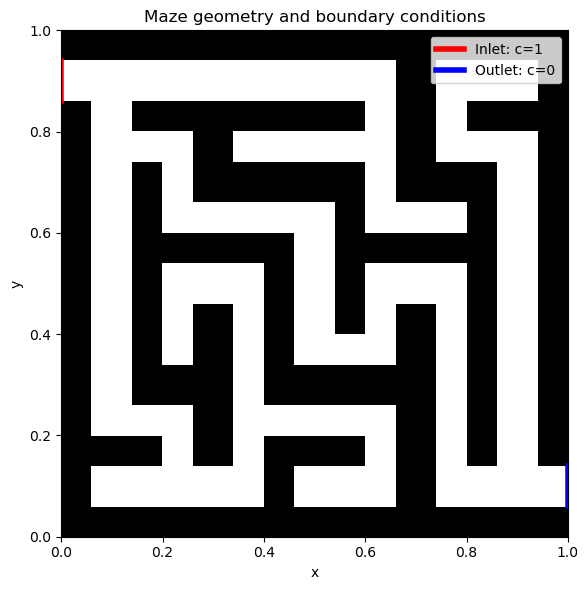

In [20]:
plt.figure(figsize=(6, 6))
plt.imshow(I, origin="lower", extent=[0, 1, 0, 1], cmap="binary", aspect="equal")
plt.plot([0, 0], [ymin_in, ymax_in], color="red", linewidth=4, label="Inlet: c=1")
plt.plot([1, 1], [ymin_out, ymax_out], color="blue", linewidth=4, label="Outlet: c=0")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Maze geometry and boundary conditions")
plt.legend()
plt.tight_layout()
plt.show()

## Problem 1.2
### Harmonic interpolation at wall–liquid interfaces

To maintain flux continuity across interfaces where the diffusion coefficient changes abruptly, we use the harmonic mean at cell faces:

$$
\alpha_e = \frac{2\alpha_P\alpha_E}{\alpha_P + \alpha_E},
\qquad
\alpha_w = \frac{2\alpha_W\alpha_P}{\alpha_W + \alpha_P},
$$

and similarly in the vertical direction. This is the interpolation is can be examined in the handwritten report and incorporated in the discrete diffusion operator below.

In [21]:
def harmonic_mean(a, b):
    return 2.0 * a * b / (a + b)


### Time-step selection for Forward Euler

For the explicit Forward Euler scheme, the stability restriction is based on the largest diffusion coefficient in the domain, which is the liquid value. We therefore choose

$$
\Delta t \leq \frac{1}{2\alpha_{\max}\left(\frac{1}{\Delta x^2} + \frac{1}{\Delta y^2}\right)},
$$

with a small safety factor.


In [22]:
print("-- Forward Euler setup")

alpha_max = alpha_liquid
dt = (1.0 / (2.0 * alpha_max * (1.0 / dx**2 + 1.0 / dy**2))) * 0.95

t_end = 50.0
nt = int(np.ceil(t_end / dt))

save_times = [1.0, 5.0, 15.0, 50.0]
saved_fields = {}

print(f"dt = {dt}")
print(f"nt = {nt}")


-- Forward Euler setup
dt = 0.00095
nt = 52632


### Transient diffusion solver

The concentration field is advanced in time using Forward Euler with a variable-coefficient diffusion operator. The face diffusion coefficients are computed with harmonic interpolation to ensure a continuous diffusive flux across wall–liquid interfaces.


t = 0.0009


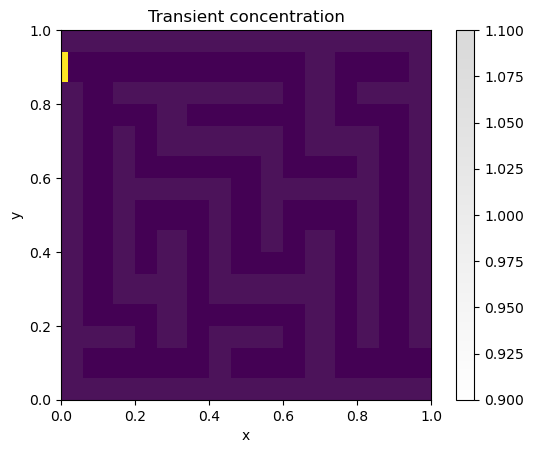

t = 7.1259


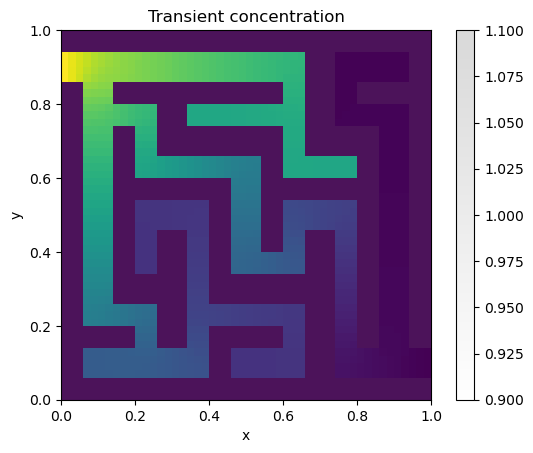

t = 14.2509


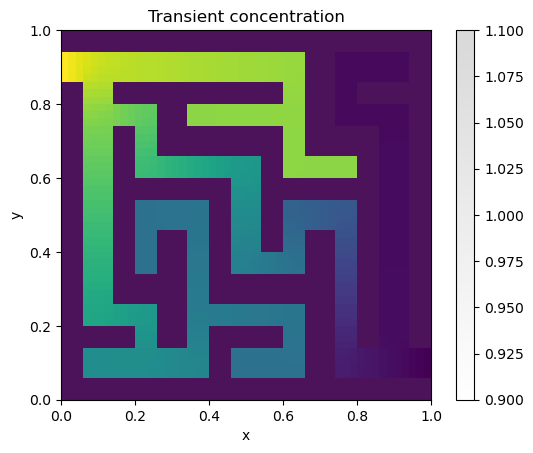

t = 21.3759


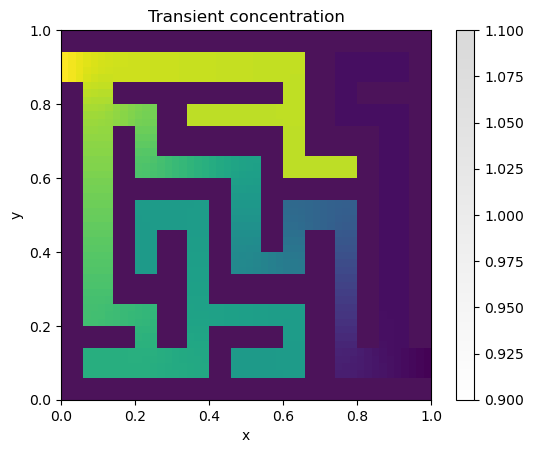

t = 28.5009


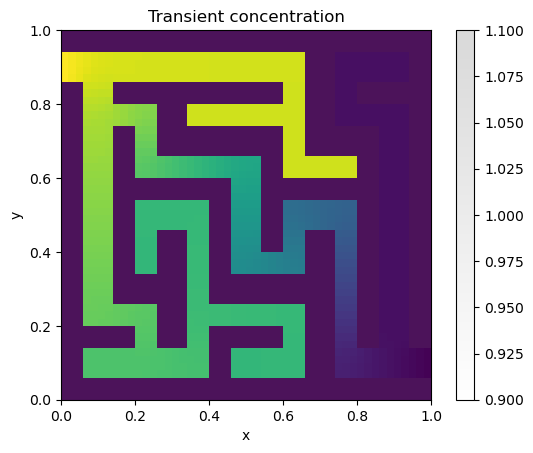

t = 35.6259


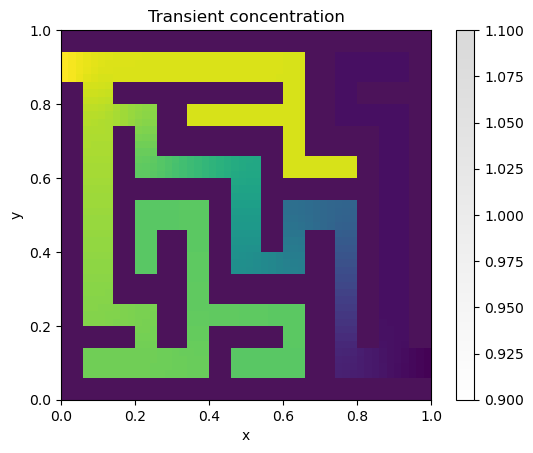

t = 42.7510


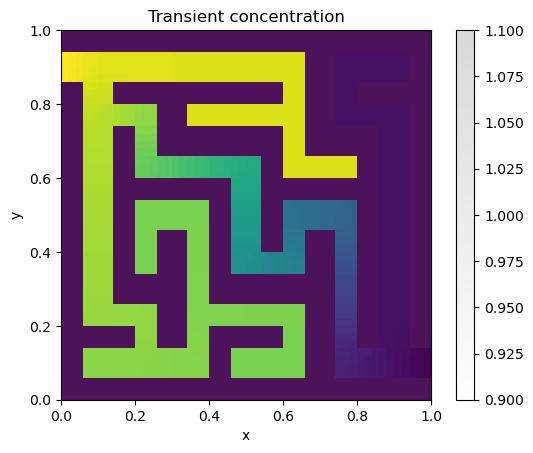

t = 49.8760


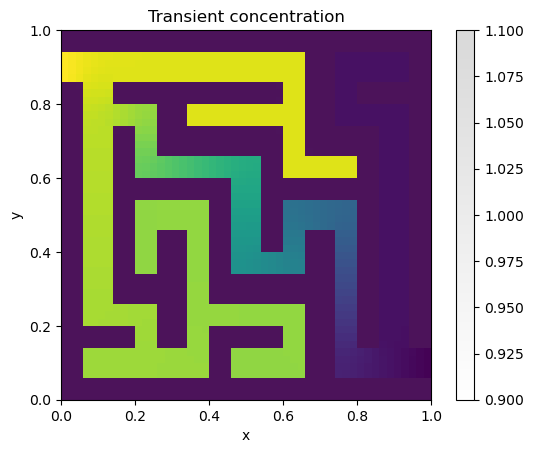

In [23]:
plt.figure()
t = 0.0

for n in range(nt):
    apply_boundary_conditions(c)
    c_old = c.copy()

    for j in range(1, Ny + 1):
        for i in range(1, Nx + 1):
            aP = alpha_g[j, i]
            aE = alpha_g[j, i + 1] if i < Nx else aP
            aW = alpha_g[j, i - 1] if i > 1 else aP
            aN = alpha_g[j + 1, i] if j < Ny else aP
            aS = alpha_g[j - 1, i] if j > 1 else aP

            alpha_e = harmonic_mean(aP, aE)
            alpha_w = harmonic_mean(aW, aP)
            alpha_n = harmonic_mean(aP, aN)
            alpha_s = harmonic_mean(aS, aP)

            diff_x = (
                alpha_e * (c_old[j, i + 1] - c_old[j, i])
                - alpha_w * (c_old[j, i] - c_old[j, i - 1])
            ) / dx**2

            diff_y = (
                alpha_n * (c_old[j + 1, i] - c_old[j, i])
                - alpha_s * (c_old[j, i] - c_old[j - 1, i])
            ) / dy**2

            c[j, i] = c_old[j, i] + dt * (diff_x + diff_y)

    t += dt

    for ts in save_times:
        if ts not in saved_fields and t >= ts:
            saved_fields[ts] = c[1:Ny+1, 1:Nx+1].copy()

    if n % 7500 == 0:
        print(f"t = {t:.4f}")
        plt.clf()

        maze_walls = np.ma.masked_where(I == 0, I)

        plt.imshow(
            c[1:Ny+1, 1:Nx+1],
            origin="lower",
            extent=[0.0, Lx, 0.0, Ly],
            cmap="viridis",
            aspect="equal",
        )
        plt.imshow(
            maze_walls,
            origin="lower",
            extent=[0.0, Lx, 0.0, Ly],
            cmap="gray_r",
            alpha=0.15,
            interpolation="nearest",
            aspect="equal",
        )

        plt.colorbar()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Transient concentration")
        plt.pause(0.01)

plt.show()


### Saved concentration snapshots

The following plots show the concentration field at the requested times.

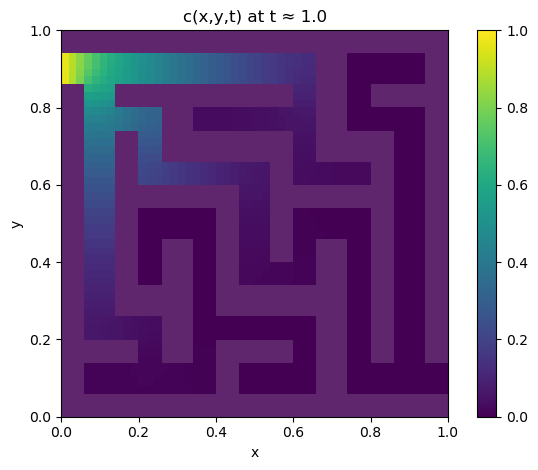

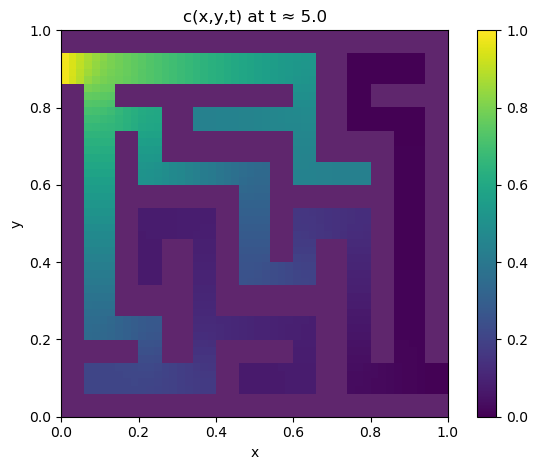

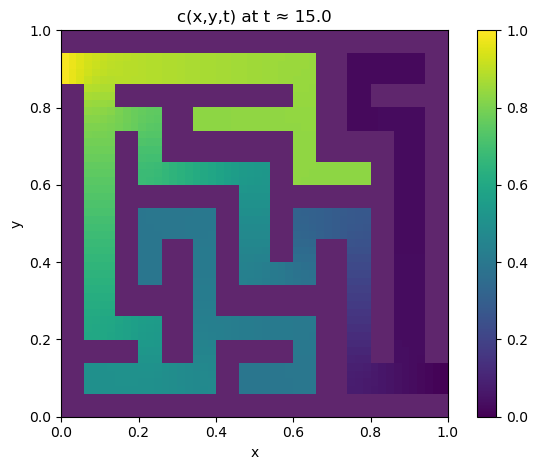

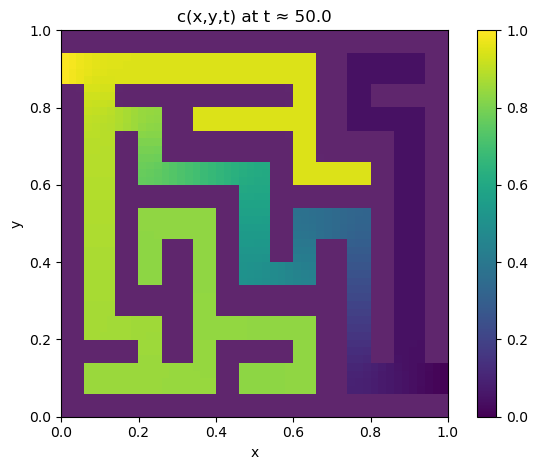

In [24]:
for ts in save_times:
    if ts in saved_fields:
        plt.figure()

        maze_walls = np.ma.masked_where(I == 0, I)

        im = plt.imshow(
            saved_fields[ts],
            origin="lower",
            extent=[0.0, Lx, 0.0, Ly],
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
            aspect="equal",
        )

        plt.imshow(
            maze_walls,
            origin="lower",
            extent=[0.0, Lx, 0.0, Ly],
            cmap="gray_r",
            alpha=0.15,
            interpolation="nearest",
            aspect="equal",
        )

        plt.colorbar(im)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title(f"c(x,y,t) at t ≈ {ts}")
        plt.tight_layout()
        plt.show()


## Problem 1.7
### Correct Maze Path

Finally the correct maze path is plotted based on the diffusive flux magnitude

In [26]:
diagnostic_quantity = np.zeros((Ny, Nx))

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):

        if (
            I[j, i] == 0
            and I[j, i + 1] == 0
            and I[j, i - 1] == 0
            and I[j + 1, i] == 0
            and I[j - 1, i] == 0
        ):
            dc_dx = (c[j+1, i+2] - c[j+1, i]) / (2*dx)
            dc_dy = (c[j+2, i+1] - c[j, i+1]) / (2*dy)

            diagnostic_quantity[j, i] = np.sqrt(dc_dx**2 + dc_dy**2)

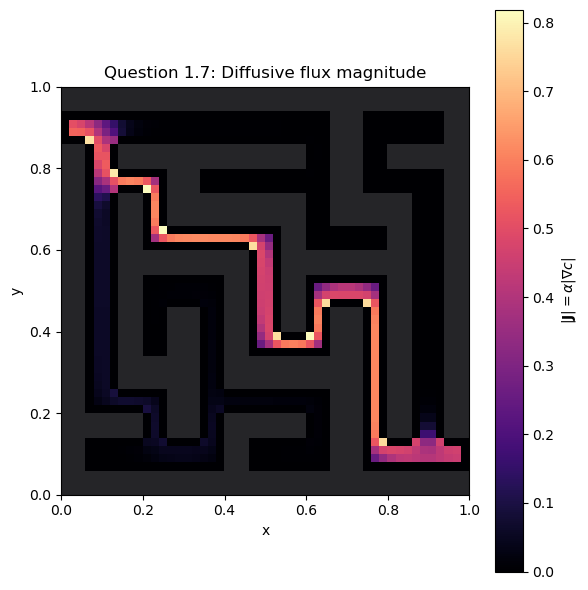

In [27]:
maze_walls = np.ma.masked_where(I == 0, I)

plt.figure(figsize=(6, 6))
im = plt.imshow(
    diagnostic_quantity,
    origin="lower",
    extent=[0.0, Lx, 0.0, Ly],
    cmap="magma",
    aspect="equal",
)

plt.imshow(
    maze_walls,
    origin="lower",
    extent=[0.0, Lx, 0.0, Ly],
    cmap="gray_r",
    alpha=0.15,
    interpolation="nearest",
    aspect="equal",
)

plt.colorbar(im, label=r"$|\mathbf{J}| = \alpha |\nabla c|$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Question 1.7: Diffusive flux magnitude")
plt.tight_layout()
plt.show()

By supressing low values below 15% of the maximum flux the path can be made clearer with more visible edges.


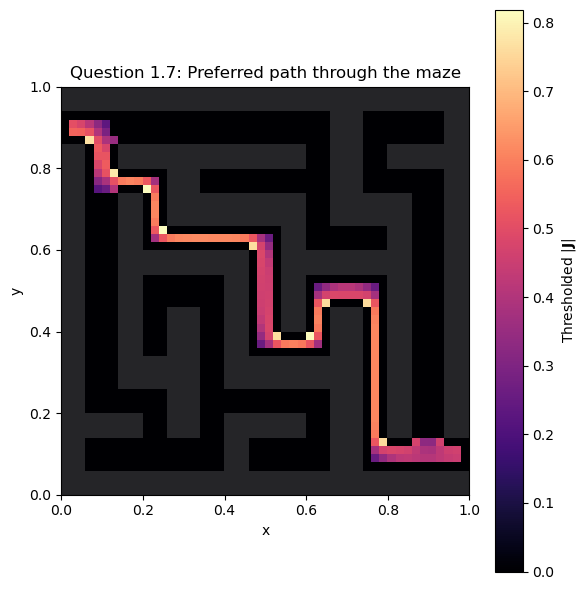

In [29]:
diagnostic_plot = diagnostic_quantity.copy()
threshold = 0.25 * diagnostic_plot.max() # Threshold value to filter out low flux regions
diagnostic_plot[diagnostic_plot < threshold] = 0.0

maze_walls = np.ma.masked_where(I == 0, I)

plt.figure(figsize=(6, 6))
im = plt.imshow(
    diagnostic_plot,
    origin="lower",
    extent=[0.0, Lx, 0.0, Ly],
    cmap="magma",
    aspect="equal",
)

plt.imshow(
    maze_walls,
    origin="lower",
    extent=[0.0, Lx, 0.0, Ly],
    cmap="gray_r",
    alpha=0.15,
    interpolation="nearest",
    aspect="equal",
)

plt.colorbar(im, label=r"Thresholded $|\mathbf{J}|$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Question 1.7: Preferred path through the maze")
plt.tight_layout()
plt.show()